In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 1. Fixing Bad Lighting (Brightening)

* **Linear transformation** – This is the most basic way to change an image. Formula: $new\_image = image \times \alpha + \beta$.       
**$\alpha$ (Alpha):** This multiplies the values. It changes the **Contrast**.      
**$\beta$ (Beta):** This adds to the values. It changes the **Brightness**.     


* **Gamma correction (Power Law)** – This is the "smart" way to brighten. It lifts the dark and middle pixels but **slows down** when it hits the bright pixels so they don't turn into giant white blobs.
**Formula:** $255 \times (pixel / 255)^g$.      
$g < 1$ makes it **brighter**.      
$g > 1$ makes it **darker**.        

In [2]:
def linear_transformation(img, alpha, beta):
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def power_law(img, gamma):
    all_possible_pixels = np.arange(256, dtype="float32")                                   # Create all possible pixel values
    table = np.clip(((all_possible_pixels / 255) ** gamma) * 255.0, 0, 255).astype('uint8') # Calculate all values for all pixels at once
    return cv2.LUT(img, table)                                                              # Apply table to the image 

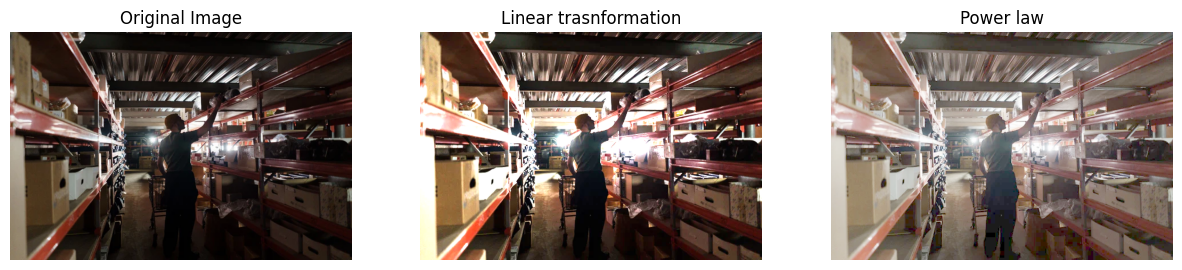

In [3]:
image = cv2.imread("../data/images/poorlight.png")

output_image1 = linear_transformation(image, 2, 1)
output_image2 = power_law(image, 0.4)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(image[...,::-1])
plt.title('Original Image')
plt.axis('off')

# Blur
plt.subplot(1, 3, 2)
plt.imshow(output_image1[...,::-1])
plt.title("Linear trasnformation")
plt.axis('off')

# Sharpen
plt.subplot(1, 3, 3)
plt.imshow(output_image2[...,::-1])
plt.title("Power law")
plt.axis('off')

plt.show()

### 2. Fixing "Foggy" Images (Small pixel range)

* **Contrast stretching** – This is a technique used to stretch a range using thresholds. We can pick a certain threshold like: if pixel is < 100, make it 0; if > 150, make it 255.
**Formula:** $s = \frac{r - r_{min}}{r_{max} - r_{min}} \times (s_{max} - s_{min}) + s_{min}$       
**$r$**: The original pixel value.      
**$r_{min}, r_{max}$**: The actual lowest and highest brightness levels currently in your image (e.g., 100 and 150).        
**$s_{min}, s_{max}$**: The target range you want (usually 0 and 255).      
**$s$**: The new, "stretched" pixel value.      


* **Histogram equalization** – This is a technique that takes an image where pixels are crowded in one small part (making it look dark or "размыто") and spreads them out across the entire 0-255 range.
**How it works:** It calculates a distribution map to ensure every brightness level is used equally.        
**Why it's used:** It is somehow very good at finding hidden details that you can't see with your eyes, which is super useful for medicine. It doesn't use a simple "Alpha" like linear transformation; instead, it uses a complex map based on the probability of each pixel value to automatically fix the image contrast.

In [4]:
def contrast_stretching(img, target_min, target_max):
    original_min = np.min(img)
    original_max = np.max(img)

    new_pixels = ((img - original_min) / (original_max - original_min)) * (target_max - target_min) + target_min
    stretched = np.uint8(new_pixels)
    return stretched

def histogram_equalization(img):
    if len(img.shape) == 3:
        (b, g, r) = cv2.split(img)
        equalized_b = cv2.equalizeHist(b)
        equalized_g = cv2.equalizeHist(g)
        equalized_r = cv2.equalizeHist(r)
        return cv2.merge([equalized_b, equalized_g, equalized_r])
    else:
        return cv2.equalizeHist(img) 

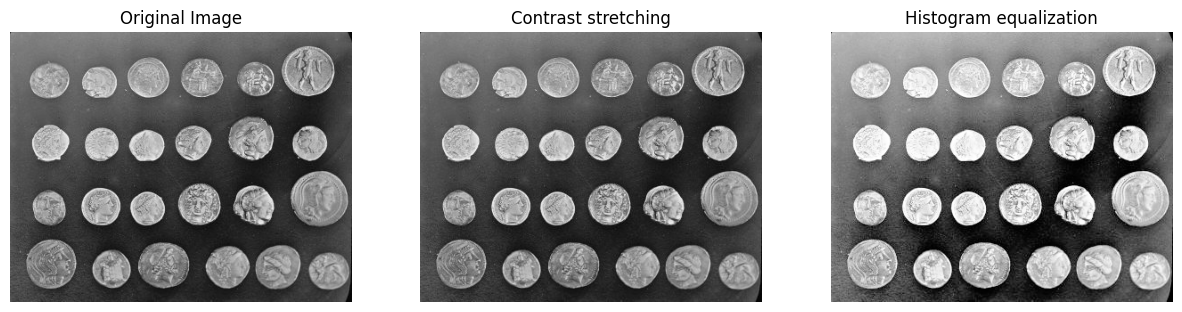

In [5]:
image = cv2.imread("../data/images/coins.png")
output_image1 = contrast_stretching(image, 0, 255)
output_image2 = histogram_equalization(image)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Blur
plt.subplot(1, 3, 2)
plt.imshow(output_image1, cmap='gray')
plt.title("Contrast stretching")
plt.axis('off')

# Sharpen
plt.subplot(1, 3, 3)
plt.imshow(output_image2, cmap='gray')
plt.title("Histogram equalization")
plt.axis('off')

plt.show()

### 3. Using Kernels (Neighborhood Processing)

* **Convolution** – This is the math where you slide a small window (Kernel) over the image. Unlike Gamma (which only looks at one pixel), this looks at the **neighbors** to decide the new value.
* **Gaussian blur** – A specific kernel that averages a pixel with its neighbors. It "melts" the image to get rid of **noise** (those tiny, annoying random dots/specks in a bad photo).
* **Sobel kernel** – A kernel used to find **edges**. It looks for where a dark pixel is right next to a bright pixel.
* **Unsharp masking** – A "triple" step:
1. Make a blurred version of the image.
2. Subtract the blur from the original (this gives you **only** the sharp edges).
3. Add those edges back to the original image to make it look high-quality.

In [6]:
"""KERNELS TO MELT NOISE AND EDGES"""

def blur_box(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Value must be positive odd")
    kernel_blur = np.ones((n, n), np.float32) / (n * n)
    return kernel_blur

def gaussian_blur(img):
    """ Manual way:
        kernel_gaussian = np.array([[1, 2, 1],
                                    [2, 4, 2],
                                    [1, 2, 1]], np.float32) / 16
        gaussian_manual = cv2.filter2D(image1, -1, kernel_gaussian)
    """
    blurred_img = cv2.GaussianBlur(img, (3, 3), 0)
    return blurred_img


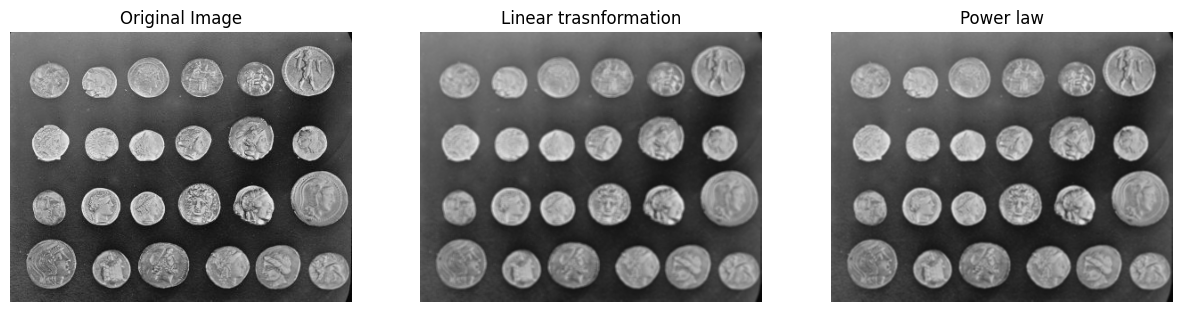

In [7]:
image = cv2.imread("../data/images/coins.png")
simple_blur_kernel = cv2.filter2D(image ,-1, blur_box(3))
gaussian_blur_kernel = gaussian_blur(image)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image[...,::-1])
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(simple_blur_kernel[...,::-1])
plt.title("Linear trasnformation")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gaussian_blur_kernel[...,::-1])
plt.title("Power law")
plt.axis('off')

plt.show()

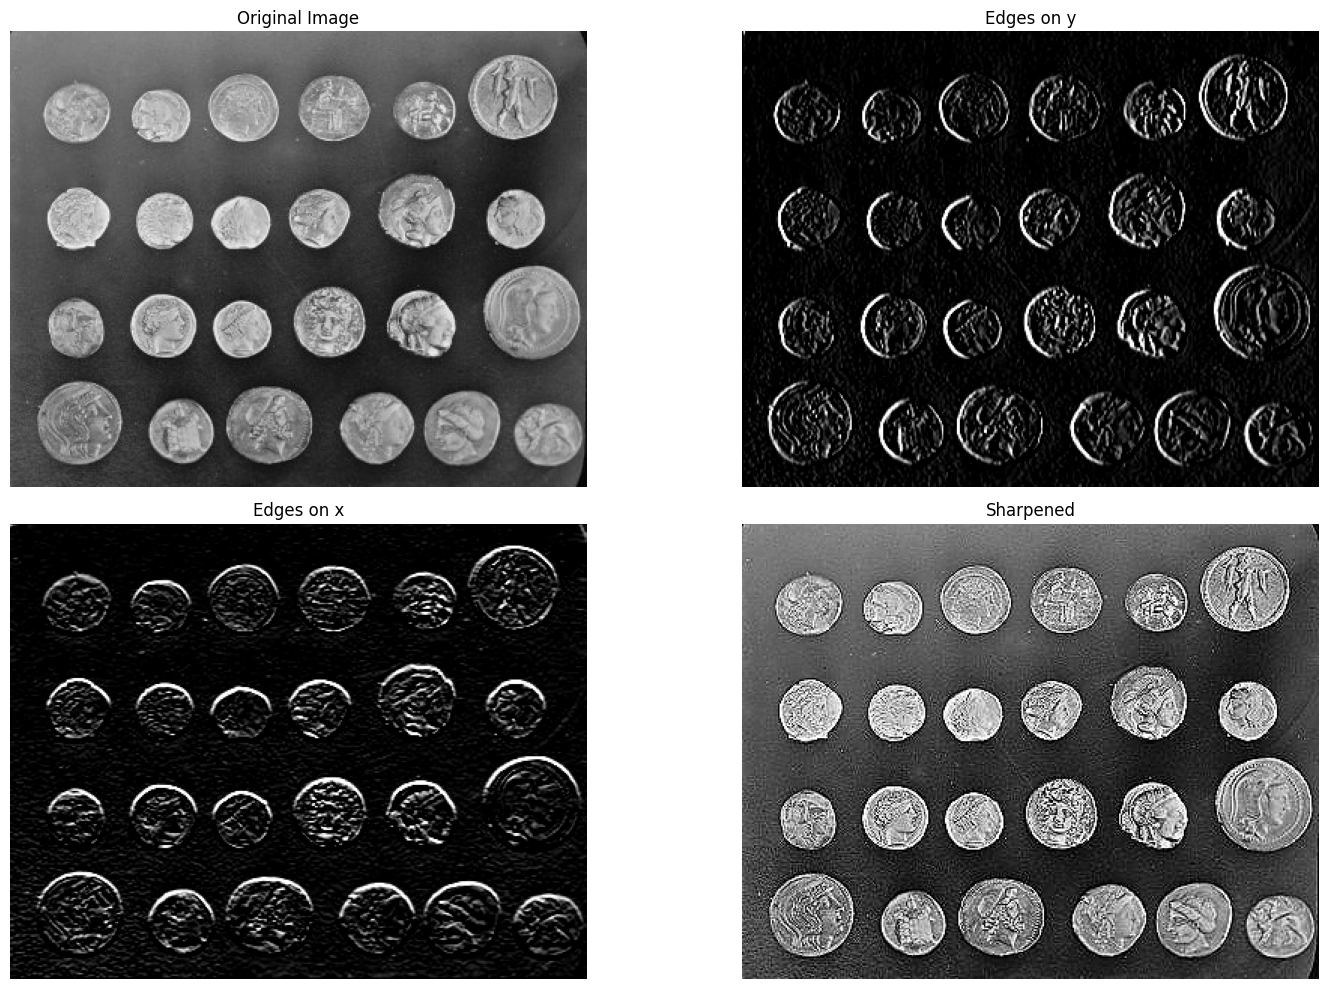

In [8]:
"""KERNELS FOR EDGE DETECTION AND IMAGE SHARPENING"""

kernel_sobel_y = np.array([[-1, 0, 1],                    # Vertical edge detection
                           [-2, 0, 2],
                           [-1, 0, 1]])

kernel_sobel_x = np.array([[-1, -2, -1],                  # Horizontal edge detection
                            [0,  0,  0],
                            [1,  2,  1]])

kernel_sharpen = np.array([[ 0, -1,  0],                  # Sharpening an image
                           [-1,  5, -1],
                           [ 0, -1,  0]])

image = cv2.imread("../data/images/coins.png")

edges_y = cv2.filter2D(image, -1, kernel_sobel_y)
edges_x = cv2.filter2D(image, -1, kernel_sobel_x)
improved_img = cv2.filter2D(image, -1, kernel_sharpen)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(edges_y)
plt.title("Edges on y")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(edges_x)
plt.title("Edges on x")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(improved_img)
plt.title("Sharpened")
plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Isolating Objects (ROI), Thresholding

* **Thresholding** – Turning a gray image into a **Binary** (Black and White) image.
* **How:** You pick a number (e.g., 156). Higher = White (The object you want/ROI). Lower = Black (The background).
* **Problem:** If one side of the image is in a shadow and the other is in bright light, one single threshold number won't work. It will turn the shadowed area completely black and you'll lose your object.

This is a technique to convert grayscale image into binary image. Why? Because binary images can be used to set foreground (ROI) and background (things we do not care about).
We set a ceratin value e.g. 156 and then go through each pixel and compare, if pixel's value bigger then 156 then it becomes 1 (white, ROI) if less becomes black. There are limitations,
since if we are dealing with images which have different, complex lightning then it will try to find details (ROI) in places where we do not care. Good for simple images.

We have different types of tresholding techniques. One is global that we discussed. Second one is Otsu's tresholding technique: It also uses one global value but it calculates it automatically, if image has two big mounatins in the histogram, meaning they have clear distiction between foreground and background. And adaptive tresholding. What it is: Instead of one treshold for the whole image, computer devides image into neighborhoods (blocks) and calculates a different treshold value for each of them. Best for images with uneven lighting. But it may falls short in areas where there is no really ROI object but it is still going to try to find it and make it white because of noise.


Otsu's calculated the best threshold value as: 102.0


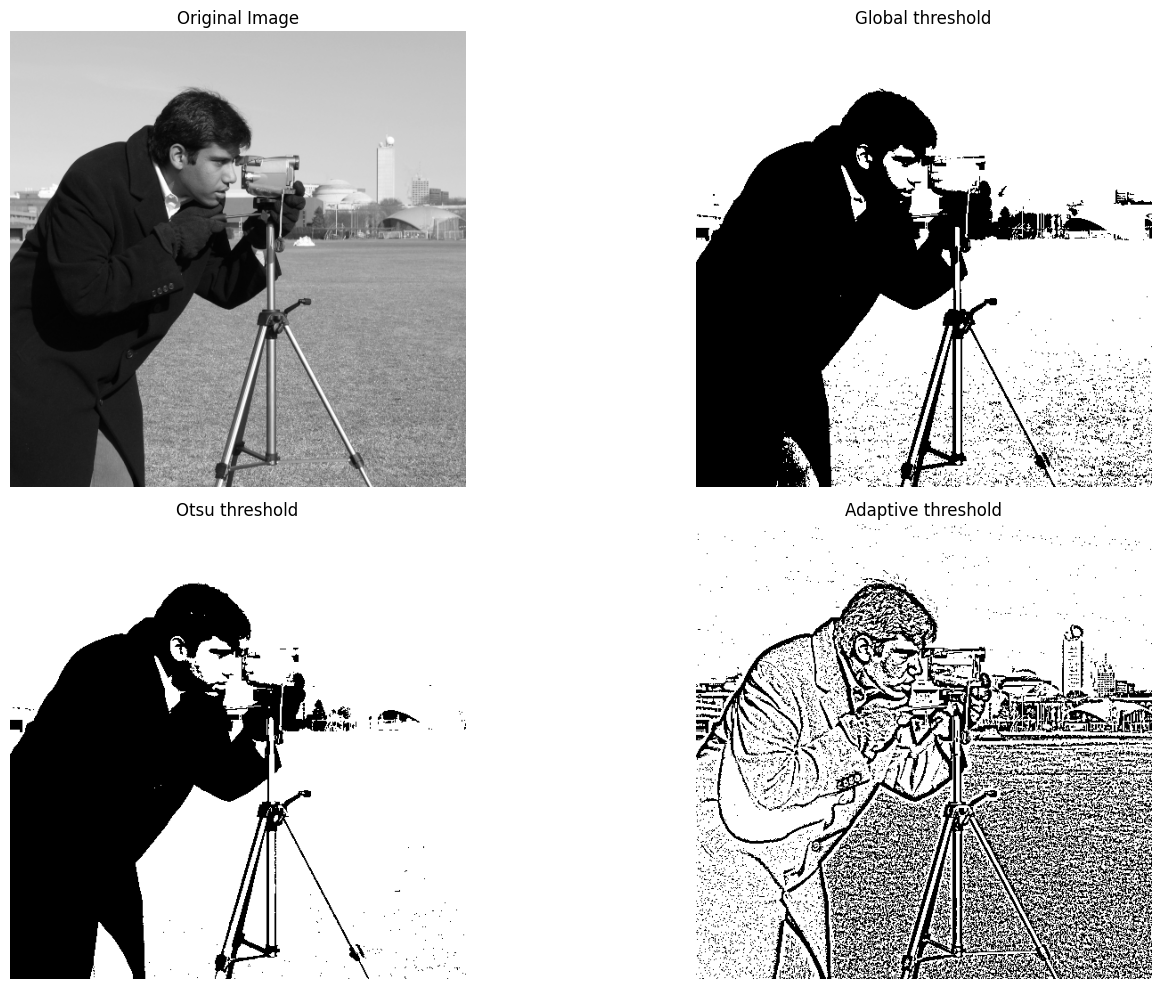

In [9]:
image = cv2.imread("../data/images/camera.png", cv2.IMREAD_GRAYSCALE)
_, global_threshold = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
val, otsu_threshold = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_threshold = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2) # 11 block size, constant subtracted from the mean
print("Otsu's calculated the best threshold value as:", val)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(global_threshold, cmap='gray')
plt.title("Global threshold")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(otsu_threshold, cmap='gray')
plt.title("Otsu threshold")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(adaptive_threshold, cmap='gray')
plt.title("Adaptive threshold")
plt.axis('off')

plt.tight_layout()
plt.show()

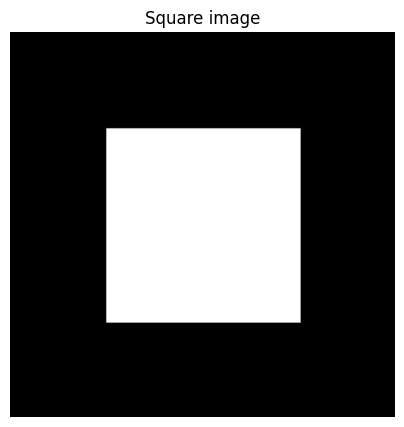

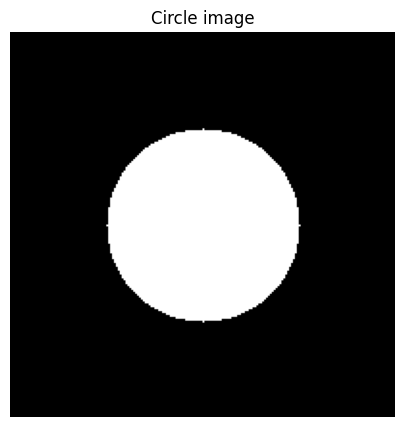

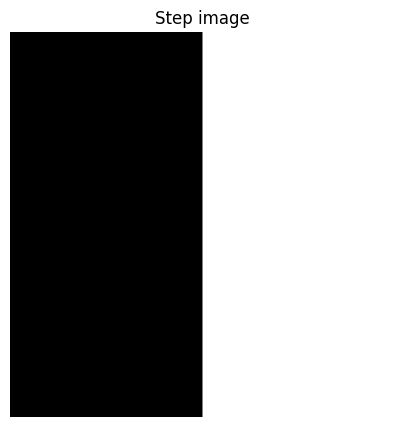

In [10]:
def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

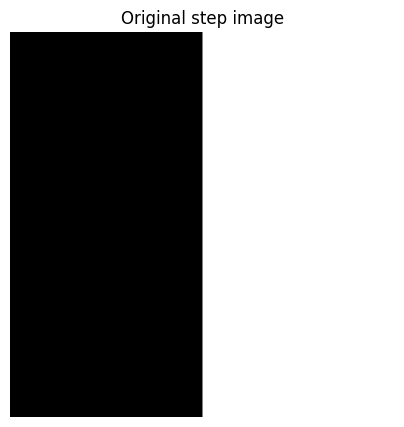

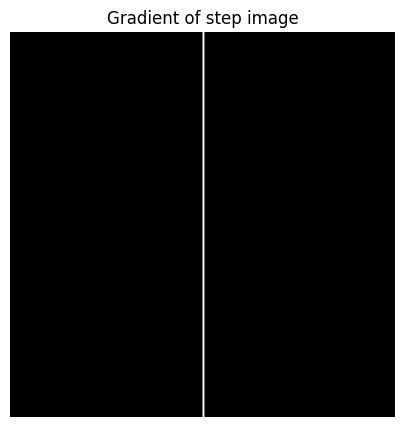

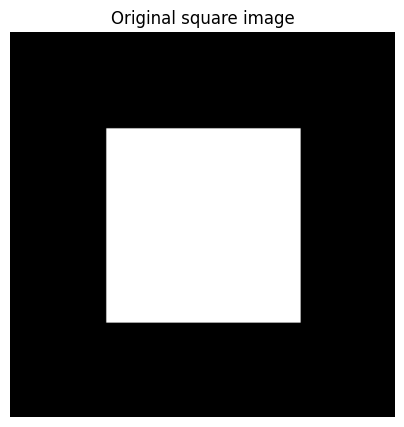

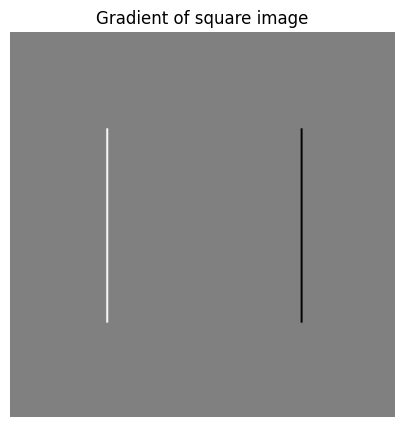

In [11]:
grad_x = np.array([[-1, 1]], dtype=np.float32)
grad_step = cv2.filter2D(img_step, cv2.CV_64F, grad_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, grad_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

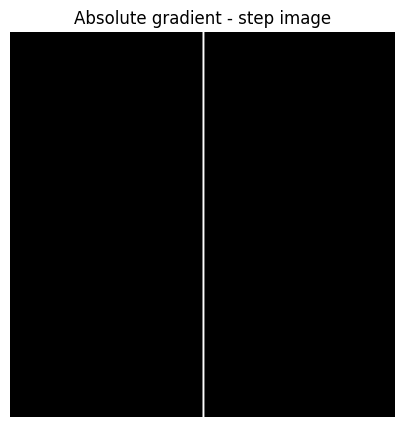

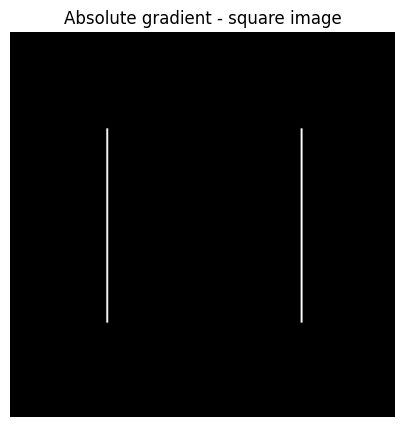

In [12]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

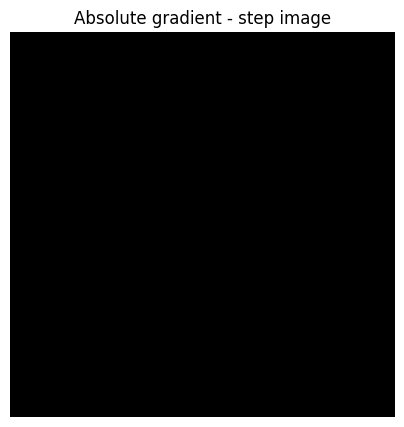

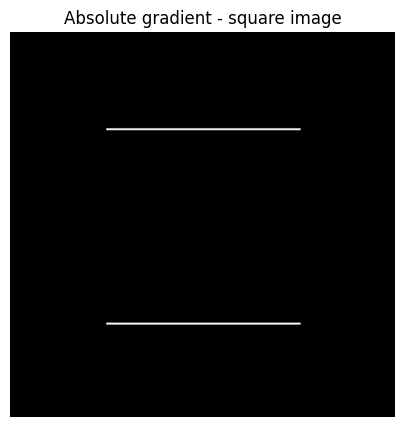

In [ ]:
grad_y = np.array([[-1], [1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, grad_y)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, grad_y)

grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

In [15]:
def simple_gradient(image, direction='x'):
    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
    else:
        raise ValueError("direction must be 'x' or 'y'")

    gradient = cv2.filter2D(image.astype(np.float32), -1, kernel)
    return gradient

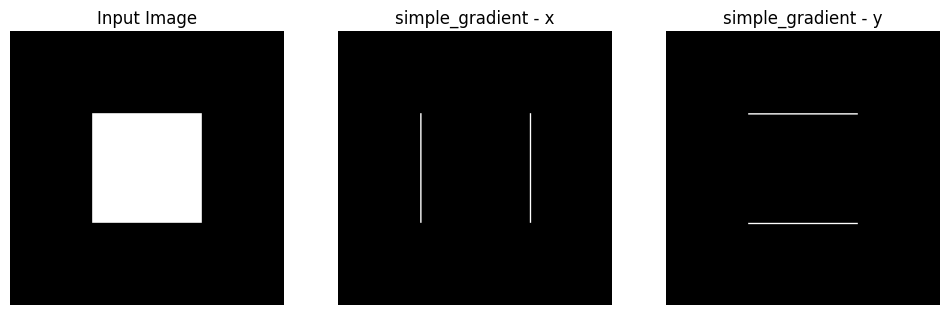

In [16]:
img = np.zeros((200, 200), dtype=np.uint8)
img[60:140, 60:140] = 255

gx = simple_gradient(img, 'x')
gy = simple_gradient(img, 'y')

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(gx), cmap='gray')
plt.title("simple_gradient - x")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.abs(gy), cmap='gray')
plt.title("simple_gradient - y")
plt.axis("off")

plt.show()

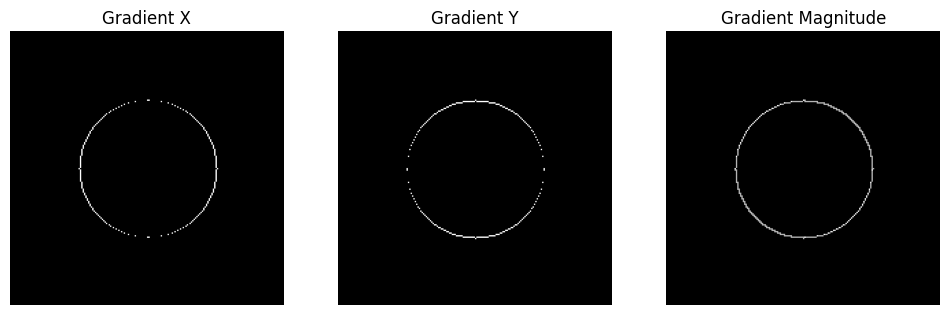

In [18]:
img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (100, 100), 50, 255, -1)

gx = simple_gradient(img, 'x')
gy = simple_gradient(img, 'y')
magnitude = np.sqrt(gx ** 2 + gy ** 2)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.abs(gx), cmap='gray')
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(gy), cmap='gray')
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()

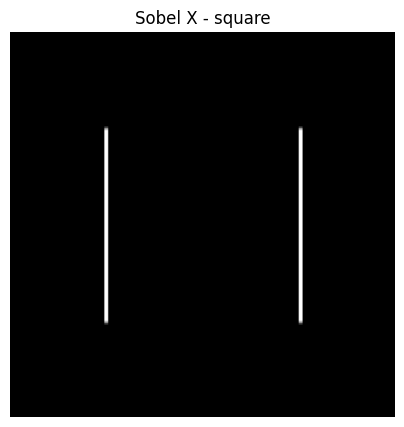

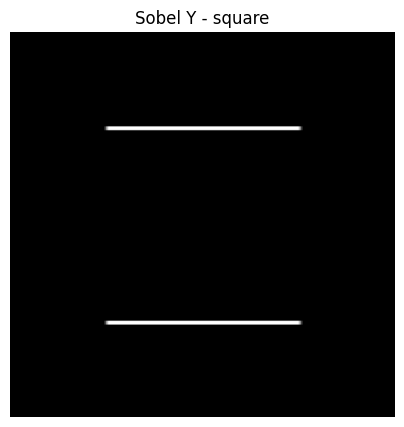

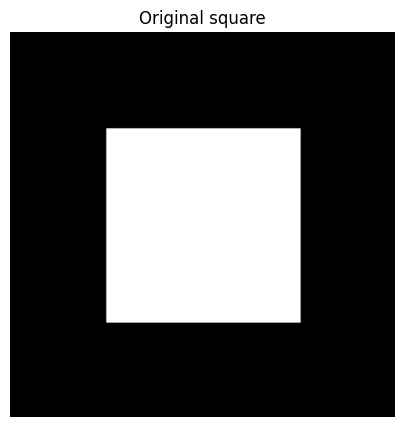

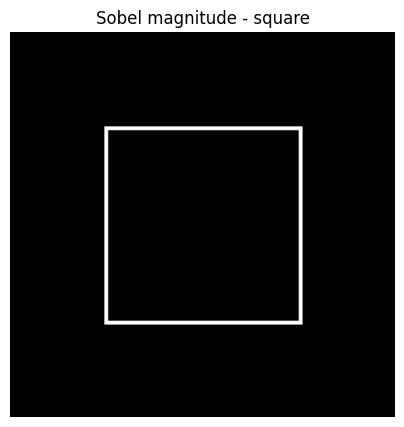

In [20]:
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

In [ ]:
def simple_gradient(img, direction='x'):
    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
    else:
        raise ValueError("Incorrect direction, choose x or y")
    edges = cv2.filter2D(img, cv2.CV_64F, kernel)
    return edges


def sobel_gradient(img, ksize=3):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=ksize)
    sobel_gradient_magnitude = np.sqrt(gx ** 2 + gy ** 2)
    
    return {"gx": gx, "gy": gy, "mag": sobel_gradient_magnitude}

In [22]:
# Squre
img_square = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)

# Circle
img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Fifty fifty
img_step = np.zeros((200, 200), dtype=np.uint8)
img_step[:, :100] = 50
img_step[:, 100:] = 220

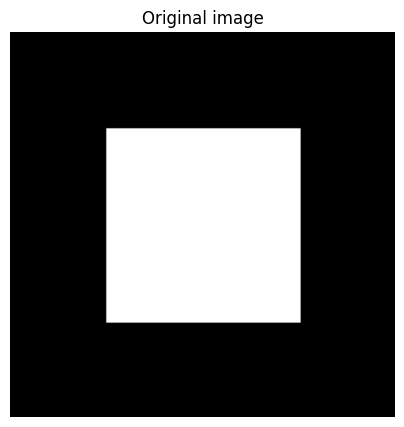

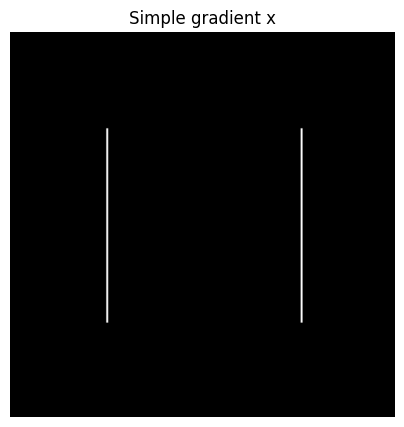

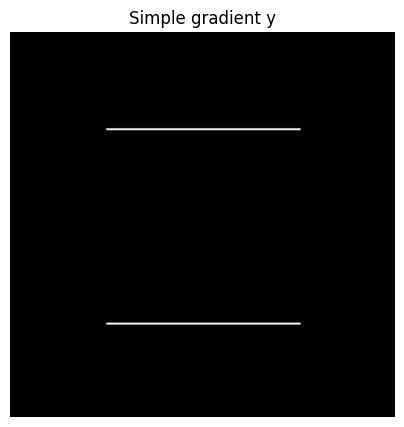

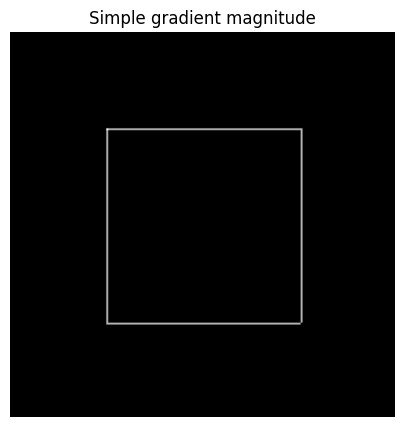

In [ ]:
result1 = simple_gradient(img_square, 'x')
result2 = simple_gradient(img_square, 'y')
result3 = np.sqrt(result1**2 + result2**2)

show(img_square, "Original image")
show(np.abs(result1), "Simple gradient x")
show(np.abs(result2), "Simple gradient y")
show(np.abs(result3), "Simple gradient magnitude")

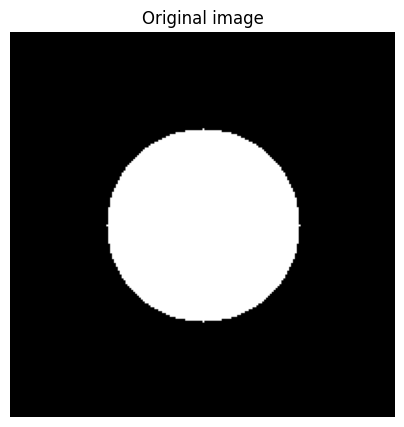

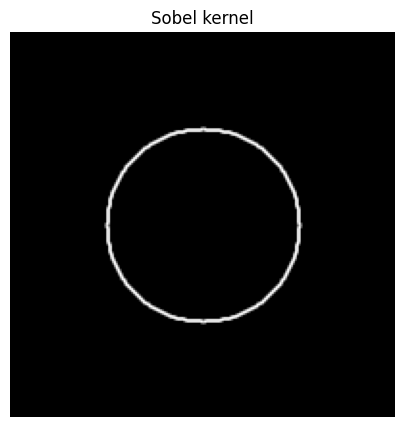

In [35]:
result1 = sobel_gradient(img_circle, 3)
show(img_circle, "Original image")
show(np.abs(result1['mag']), "Sobel kernel")